# Sales Prediction using Advertising Data
This project predicts sales based on advertising spend across TV, Radio, and Newspaper, 
using a Linear Regression model.

## 1. Load and Explore the Dataset

In [16]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Advertising.csv')

# Drop the 'Unnamed: 0' column - it's just a row index, not useful data
df = df.drop('Unnamed: 0', axis=1)

# Look at the first 5 rows
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [7]:
# How many rows and columns?
print(df.shape)

# Data types and missing value overview
print(df.info())

# Confirm no missing values
print(df.isnull().sum())

# Quick statistics summary
print(df.describe())

(200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
7

## 2. Visualize Relationships Between Advertising Spend and Sales

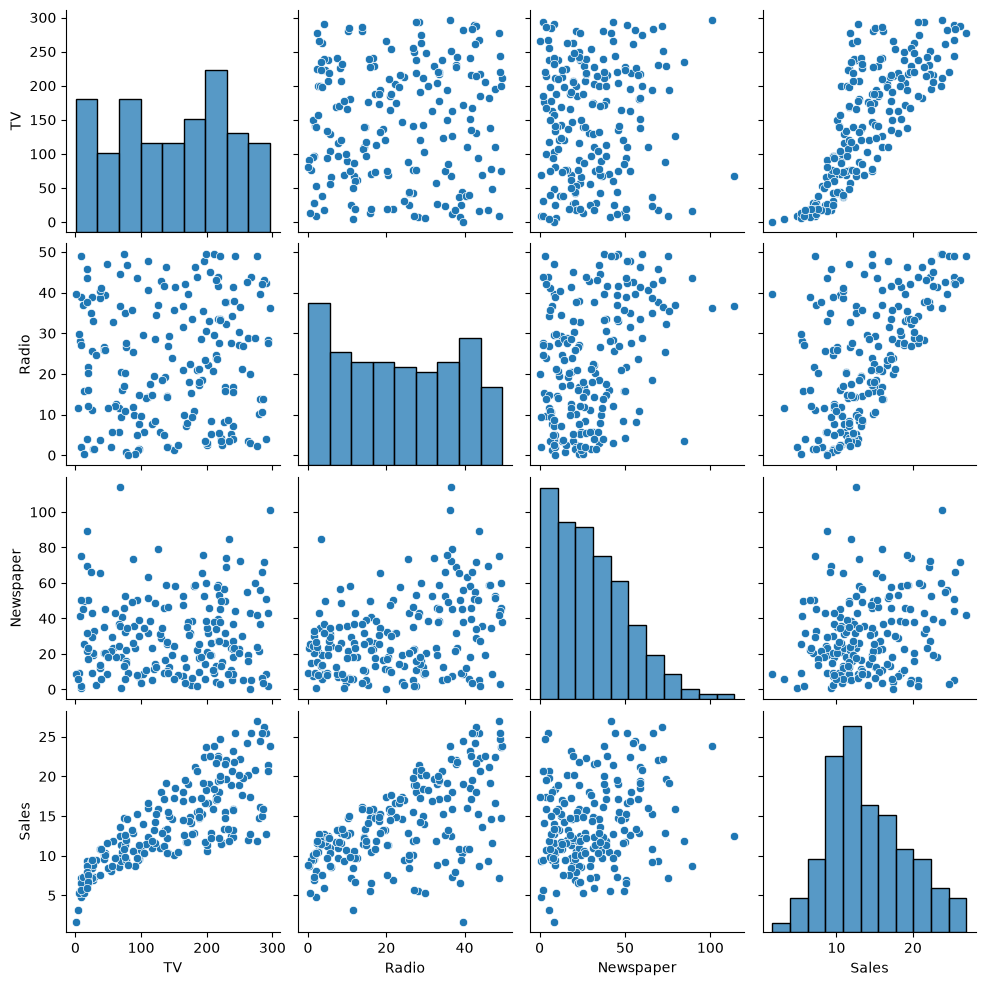

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot to see relationships between advertising spend and sales
sns.pairplot(df)
plt.show()

## 3. Split Data for Training and Testing

In [11]:
from sklearn.model_selection import train_test_split

# X = input features (advertising spend across TV, Radio, Newspaper)
X = df.drop('Sales', axis=1)

# y = target (what we want to predict - Sales)
y = df['Sales']

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (160, 3)
Testing data size: (40, 3)


## 4. Train a Linear Regression Model

In [12]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train it using the training data
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


## 5. Evaluate Model Performance

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Ask the model to predict sales for the test data (unseen data)
y_pred = model.predict(X_test)

# Calculate different error metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.3116924478229166
Mean Squared Error (MSE): 3.183073937014937
Root Mean Squared Error (RMSE): 1.784117130968406
R² Score: 0.8814493187306122


## 6. Actual vs Predicted Sales

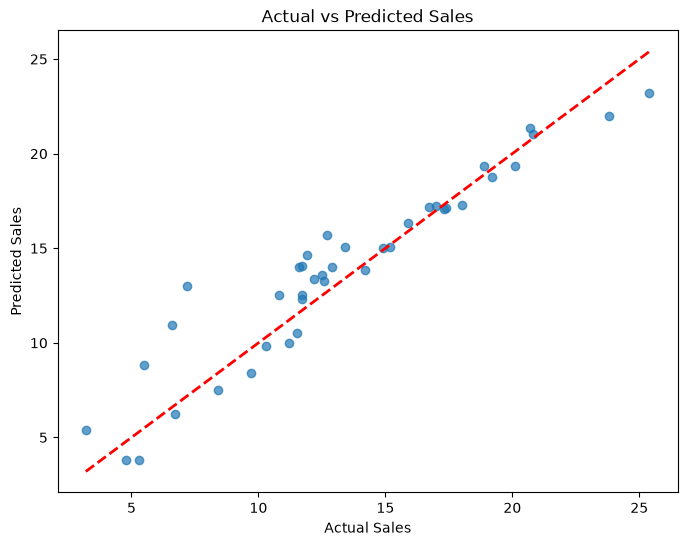

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()

## 7. Check Feature Importance

In [15]:
# See how much weight the model gave to each advertising channel
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)
print("\nIntercept (baseline sales):", model.intercept_)

     Feature  Coefficient
0         TV     0.044804
1      Radio     0.187184
2  Newspaper     0.006098

Intercept (baseline sales): 3.0086731491088727
